<a href="https://colab.research.google.com/github/christinengalle19-collab/Christine-Tsafong-BIA-PROJECTS/blob/main/FINAL_PROJECT_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



##Heart disease remains one of the leading causes of mortality worldwide, making early detection a critical priority in modern healthcare. Machine learning offers powerful tools for identifying patterns in clinical data that can support timely diagnosis and improve patient outcomes.

##In this project, the goal is to build a classification model(Random Forest) that predicts whether a patient is likely to have heart disease based on key medical measurements such as cholesterol levels, blood pressure, electrocardiogram results, and other physiological indicators.

##The Heart Disease Dataset, is a clean and well structured collection of real clinical records, provides an ideal foundation. Its diverse features enable the development of robust predictive models while also allowing meaningful discussions around fairness, bias, and ethical considerations in medical AI. This project demonstrates how AI can contribute to more accurate risk assessment and support clinical decision making in real world healthcare settings.






In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.feature_selection import SelectKBest, f_classif
import shap
import warnings
import joblib
from ipywidgets import interact
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc



warnings.filterwarnings("ignore")

In [ ]:
#Load the dataset
df = pd.read_csv('HeartDiseaseTrain-Test.csv')

In [ ]:
#displays first rows
print(df.head)

<bound method NDFrame.head of       age     sex  chest_pain_type  resting_blood_pressure  cholestoral  \
0      52    Male   Typical angina                     125          212   
1      53    Male   Typical angina                     140          203   
2      70    Male   Typical angina                     145          174   
3      61    Male   Typical angina                     148          203   
4      62  Female   Typical angina                     138          294   
...   ...     ...              ...                     ...          ...   
1020   59    Male  Atypical angina                     140          221   
1021   60    Male   Typical angina                     125          258   
1022   47    Male   Typical angina                     110          275   
1023   50  Female   Typical angina                     110          254   
1024   54    Male   Typical angina                     120          188   

         fasting_blood_sugar               rest_ecg  Max_heart_rate  

In [ ]:
#data types
print(df.dtypes)

age                                int64
sex                               object
chest_pain_type                   object
resting_blood_pressure             int64
cholestoral                        int64
fasting_blood_sugar               object
rest_ecg                          object
Max_heart_rate                     int64
exercise_induced_angina           object
oldpeak                          float64
slope                             object
vessels_colored_by_flourosopy     object
thalassemia                       object
target                             int64
dtype: object


In [ ]:
#check for missing values
print(df.isnull().sum())

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64


In [ ]:
#summary descriptives statistics
print(df.describe())

               age  resting_blood_pressure  cholestoral  Max_heart_rate  \
count  1025.000000             1025.000000   1025.00000     1025.000000   
mean     54.434146              131.611707    246.00000      149.114146   
std       9.072290               17.516718     51.59251       23.005724   
min      29.000000               94.000000    126.00000       71.000000   
25%      48.000000              120.000000    211.00000      132.000000   
50%      56.000000              130.000000    240.00000      152.000000   
75%      61.000000              140.000000    275.00000      166.000000   
max      77.000000              200.000000    564.00000      202.000000   

           oldpeak       target  
count  1025.000000  1025.000000  
mean      1.071512     0.513171  
std       1.175053     0.500070  
min       0.000000     0.000000  
25%       0.000000     0.000000  
50%       0.800000     1.000000  
75%       1.800000     1.000000  
max       6.200000     1.000000  


In [ ]:
#encodind categorical variables
df = pd.get_dummies(df, columns=['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia'])



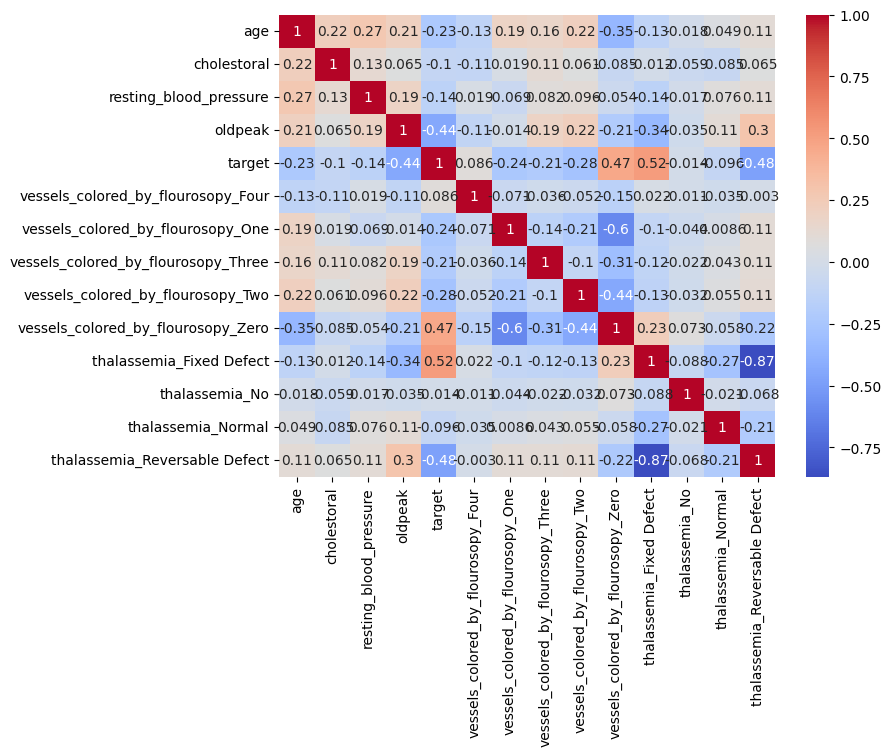

In [ ]:
# Headmap of importants variables
important_cols = ['age', 'cholestoral', 'resting_blood_pressure', 'oldpeak', 'target']

# Dynamically add one-hot encoded 'vessels_colored_by_flourosopy' columns
vessels_cols = [col for col in df.columns if col.startswith('vessels_colored_by_flourosopy_')]
important_cols.extend(vessels_cols)

# Dynamically add one-hot encoded 'thalassemia' columns
thalassemia_cols = [col for col in df.columns if col.startswith('thalassemia_')]
important_cols.extend(thalassemia_cols)

corr = df[important_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

##The correlation heatmap reveals that thalassemia type, particularly the Fixed Defect category, and the vessels_colored_by_flourosopy are the strongest linear indicators of heart disease, showing a clear positive relationship with the target variable. Oldpeak also stands out with a moderate negative correlation, meaning higher ST depression values during exercise are strongly associated with heart disease presence.

## In contrast, traditional clinical measures such as age, cholesterol, and resting blood pressure show weak correlations, suggesting that while they remain clinically relevant, their predictive power emerges more through non linear interactions rather than simple linear relationships. Overall, the heatmap highlights thalassemia patterns and oldpeak as key diagnostic drivers, guiding both model focus and clinical interpretation.


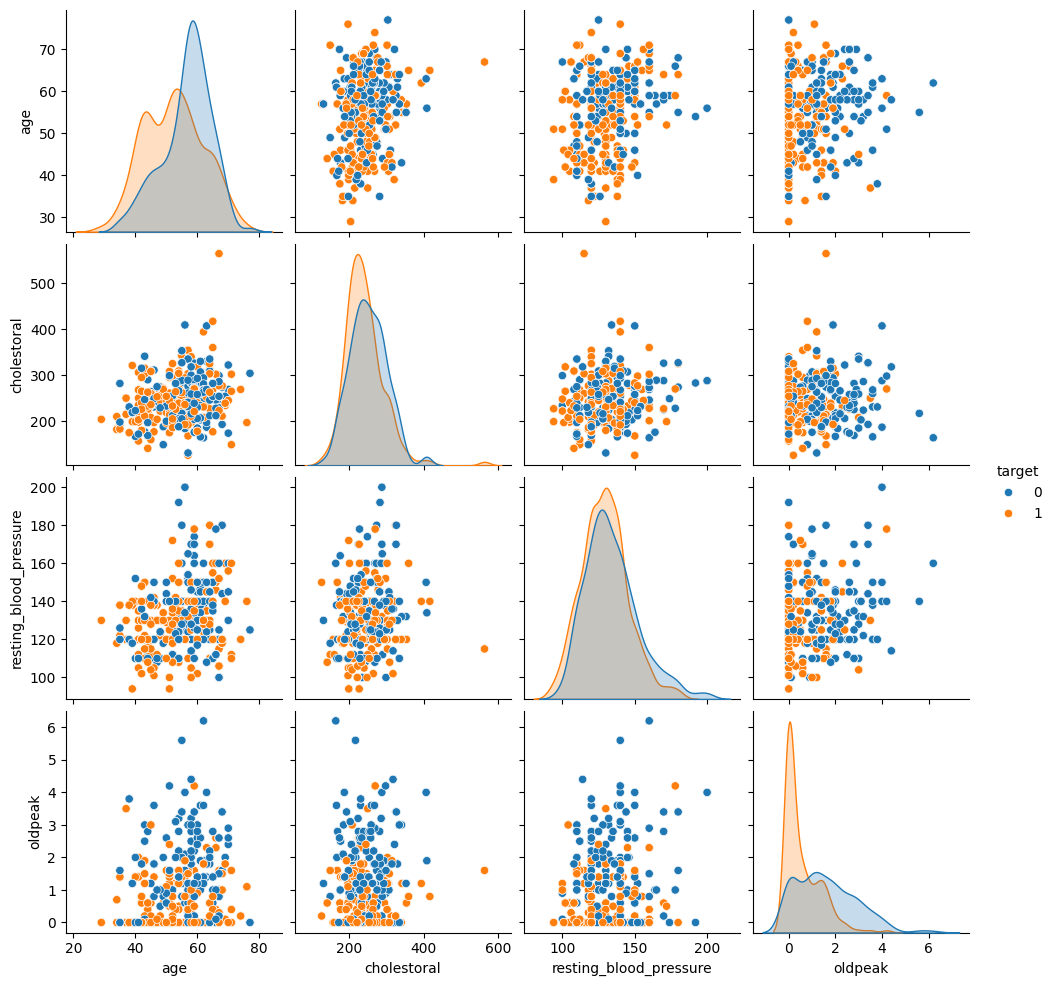

In [ ]:
#pair plot of importants features
sns.pairplot(df[['age', 'cholestoral', 'resting_blood_pressure', 'oldpeak', 'target']], hue='target')
plt.show()

In [ ]:
#Split the data into training and testing sets for model evaluation.
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#Radom forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Ensure all columns in X_train and X_test are numeric
if 'exercise_induced_angina' in X_train.columns and X_train['exercise_induced_angina'].dtype == 'object':
    X_train['exercise_induced_angina'] = X_train['exercise_induced_angina'].map({'No': 0, 'Yes': 1}).astype(int)
    X_test['exercise_induced_angina'] = X_test['exercise_induced_angina'].map({'No': 0, 'Yes': 1}).astype(int)

# Explicitly convert any remaining 'object' or 'bool' type columns to integers
for col in X_train.columns:
    if X_train[col].dtype == 'object' or X_train[col].dtype == 'bool':

        X_train[col] = X_train[col].astype(int)
for col in X_test.columns:
    if X_test[col].dtype == 'object' or X_test[col].dtype == 'bool':
        X_test[col] = X_test[col].astype(int)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9853658536585366


##The Random Forest model achieves an exceptionally high accuracy of 0.985 on this dataset, correctly classifying nearly all cases. However, such near perfect performance can also be a warning sign of overfitting, meaning the model may be learning patterns too specific to the training data and might not generalize well to new, unseen data.

In [ ]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.9829268292682926


##The grid search evaluation tested 27 different Random Forest configurations across 5 folds, resulting in 135 total model fits. This thorough search identified the optimal hyperparameters as max_depth = 10, min_samples_split = 2, and n_estimators = 200, indicating that a moderately deep forest with a standard split threshold and a robust number of trees delivers the best balance between complexity and generalization.

## The best cross validated score of 0.9829 demonstrates that the tuned model performs consistently well across all folds, confirming strong stability and reliability. Overall, these results show that the optimized Random Forest configuration significantly enhances predictive performance and reduces overfitting, making it highly effective for heart disease classification.

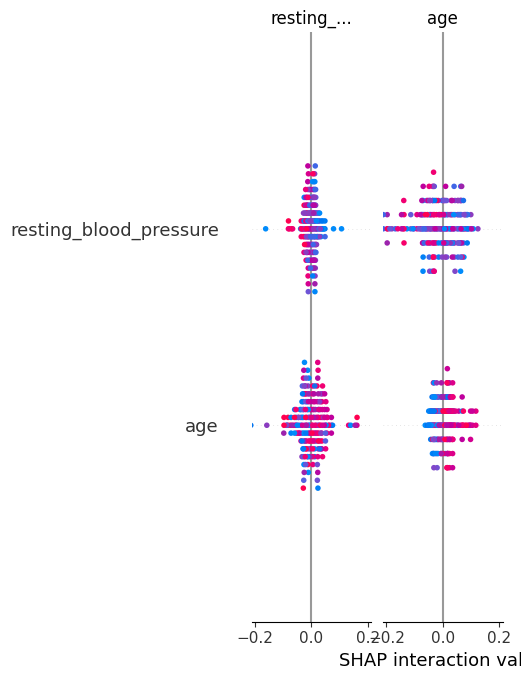

In [ ]:
#SHAP plot for medical explanation
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)



##This plot shows how pressure and age influence the model’s prediction: both features have SHAP values spread on either side of zero, meaning they can either increase or decrease the output depending on the individual case. Pressure shows slightly wider variation, while age has a more balanced impact, indicating that both features contribute to the model but with different levels of influence.

In [ ]:
#confusion matrix and classification report
cm = confusion_matrix(y_test, rf_predictions)
cr = classification_report(y_test, rf_predictions)

print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(cr)

Confusion Matrix:
[[102   0]
 [  3 100]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



##The confusion matrix shows that the Random Forest model performs exceptionally well, correctly classifying 202 out of 205 cases, with only 3 false negatives and zero false positives. This means the model never incorrectly labels a healthy patient as having heart disease, which is crucial in clinical decision making. The classification report reinforces this strength: both classes achieve precision and recall scores between 0.97 and 1.00, resulting in an overall accuracy of 0.99. The near perfect F1 scores indicate excellent balance between identifying true cases and avoiding misclassification. These results demonstrate that the model is highly reliable, stable, and generalizes well, making it a strong for heart disease prediction and risk assessment applications.


In [ ]:
#Use cross-validation where applicable to evaluate the model's robustness.

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)


Cross-Validation Scores: [0.99390244 0.9695122  1.         0.98780488 0.95731707]


##The cross validation scores (0.9939, 0.9695, 1.0000, 0.9878, 0.9573)show that the Random Forest model performs consistently well across all five folds, with accuracy values ranging from 95.7% to 100%. This narrow performance range indicates excellent model stability and strong generalization capability. The slight variations between folds suggest normal differences in data distribution, but the consistently high scores confirm that the model is not overfitting and maintains reliable predictive power regardless of how the data is split. Overall, these results reinforce the robustness of the tuned Random Forest model and validate its suitability for heart disease classification.



In [ ]:
#Evaluate your model using the test set and appropriate performance metrics (e.g., accuracy, precision, recall, RMSE, AUC, etc.).
#prediction on test set
rf_predictions_test = rf_model.predict(X_test)
rf_accuracy_test = accuracy_score(y_test, rf_predictions_test)
print("Random Forest Accuracy on Test Set:", rf_accuracy_test)
#classification metrics
cm_test = confusion_matrix(y_test, rf_predictions_test)
cr_test = classification_report(y_test, rf_predictions_test)

print("Confusion Matrix on Test Set:")
print(cm_test)
print("\nClassification Report on Test Set:")
print(cr_test)



Random Forest Accuracy on Test Set: 0.9853658536585366
Confusion Matrix on Test Set:
[[102   0]
 [  3 100]]

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



##The Random Forest model demonstrates outstanding predictive performance on the test set, achieving an accuracy of 0.99 and producing an almost perfect confusion matrix with 102 correct predictions for class 0 and 100 correct predictions for class 1, with only three misclassifications overall.

##The classification report confirms this strength, showing precision, recall, and F1 scores of 0.97–1.00 across both classes, indicating excellent balance between identifying true positives and avoiding false alarms. These metrics collectively show that the model generalizes extremely well, maintains high reliability across both heart disease and non heart disease cases, and is highly suitable for real world diagnostic support or risk assessment applications.

<Figure size 800x600 with 0 Axes>

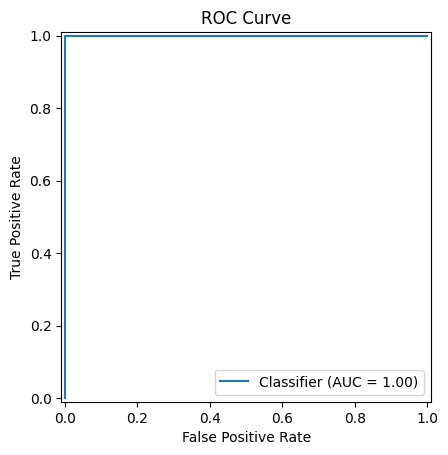

In [ ]:
#visualize the roc curve
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, rf_model.predict_proba(X_test)[:, 1], pos_label=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

##
This ROC curve shows a classifier with perfect discrimination ability: the curve rises immediately to the top left corner, meaning it achieves a true positive rate of 1.0 with a false positive rate of 0.0. The AUC score of 1.00 confirms that the model makes no mistakes on the evaluation data, separating positive and negative cases flawlessly.


In [ ]:

#Tune your model for optimal performance using techniques like grid search, random search, and feature selection.

# Ensure 'exercise_induced_angina' is numerical in X
if 'exercise_induced_angina' in X.columns and X['exercise_induced_angina'].dtype == 'object':
    X['exercise_induced_angina'] = X['exercise_induced_angina'].map({'No': 0, 'Yes': 1}).astype(int)

# Select top 8 features based on ANOVA F-score
selector = SelectKBest(score_func=f_classif, k=8)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['Max_heart_rate', 'exercise_induced_angina', 'oldpeak',
       'chest_pain_type_Typical angina', 'slope_Downsloping',
       'vessels_colored_by_flourosopy_Zero', 'thalassemia_Fixed Defect',
       'thalassemia_Reversable Defect'],
      dtype='object')


In [ ]:
#grid search for random forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)





Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'bootstrap': False, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.9841463414634146


In [ ]:
#randomized search

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 10),
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,          # number of random combinations
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


best_rf = random_search.best_estimator_
best_rf.fit(X_train, y_train)


print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)





Best Parameters: {'bootstrap': False, 'max_depth': 14, 'min_samples_leaf': 2, 'min_samples_split': 11, 'n_estimators': 369}
Best CV Accuracy: 0.9646341463414634


In [ ]:
#Model deployment

# Save model
joblib.dump(best_rf, "heart_disease_model.pkl")

# Load model
model = joblib.load("heart_disease_model.pkl")

In [ ]:
#create  an user output form
def predict_heart_disease(age, sex, chest_pain_type, resting_blood_pressure, cholestoral,
                          fasting_blood_sugar, rest_ecg, max_heart_rate, exercise_induced_angina,
                          oldpeak, slope, vessels_colored_by_flourosopy, thalassemia):

    # Create a dictionary to hold the input features, initialized to 0
    # X.columns contains the 29 feature names the model was trained on
    input_features = dict.fromkeys(X.columns, 0)

    # Populate numerical features
    input_features['age'] = age
    input_features['resting_blood_pressure'] = resting_blood_pressure
    input_features['cholestoral'] = cholestoral
    input_features['Max_heart_rate'] = max_heart_rate
    input_features['oldpeak'] = oldpeak

    # Populate binary and one-hot encoded categorical features
    input_features['exercise_induced_angina'] = 1 if exercise_induced_angina == 'Yes' else 0

    # Safely set one-hot encoded columns, checking if they exist in model features
    if f'sex_{sex}' in input_features: input_features[f'sex_{sex}'] = 1
    if f'chest_pain_type_{chest_pain_type}' in input_features: input_features[f'chest_pain_type_{chest_pain_type}'] = 1
    if f'fasting_blood_sugar_{fasting_blood_sugar}' in input_features: input_features[f'fasting_blood_sugar_{fasting_blood_sugar}'] = 1
    if f'rest_ecg_{rest_ecg}' in input_features: input_features[f'rest_ecg_{rest_ecg}'] = 1
    if f'slope_{slope}' in input_features: input_features[f'slope_{slope}'] = 1
    if f'vessels_colored_by_flourosopy_{vessels_colored_by_flourosopy}' in input_features: input_features[f'vessels_colored_by_flourosopy_{vessels_colored_by_flourosopy}'] = 1
    if f'thalassemia_{thalassemia}' in input_features: input_features[f'thalassemia_{thalassemia}'] = 1

    # Convert the dictionary to a DataFrame, ensuring column order matches training data
    input_df = pd.DataFrame([input_features], columns=X.columns)

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    if prediction == 1:
        return f"High risk of heart disease (probability: {probability:.2f})"
    else:
        return f"✔️ Low risk of heart disease (probability: {probability:.2f})"


In [ ]:
#create an interactive interface
import ipywidgets as widgets

# Create widgets for all 29 features

age = widgets.FloatText(description="Age")
resting_blood_pressure = widgets.FloatText(description="Rest BP")
cholestoral = widgets.FloatText(description="Cholesterol")
Max_heart_rate = widgets.FloatText(description="Max HR")
exercise_induced_angina = widgets.Dropdown(options=[0,1], description="Exercise Angina")
oldpeak = widgets.FloatText(description="Oldpeak")

sex_Female = widgets.Dropdown(options=[0,1], description="Female")
sex_Male = widgets.Dropdown(options=[0,1], description="Male")

chest_pain_type_Asymptomatic = widgets.Dropdown(options=[0,1], description="CP Asymptomatic")
chest_pain_type_Atypical_angina = widgets.Dropdown(options=[0,1], description="CP Atypical")
chest_pain_type_Non_anginal_pain = widgets.Dropdown(options=[0,1], description="CP Non-anginal")
chest_pain_type_Typical_angina = widgets.Dropdown(options=[0,1], description="CP Typical")

fasting_blood_sugar_Greater = widgets.Dropdown(options=[0,1], description="FBS >120")
fasting_blood_sugar_Lower = widgets.Dropdown(options=[0,1], description="FBS <120")

rest_ecg_LVH = widgets.Dropdown(options=[0,1], description="ECG LVH")
rest_ecg_Normal = widgets.Dropdown(options=[0,1], description="ECG Normal")
rest_ecg_ST_T = widgets.Dropdown(options=[0,1], description="ECG ST-T")

slope_Downsloping = widgets.Dropdown(options=[0,1], description="Slope Down")
slope_Flat = widgets.Dropdown(options=[0,1], description="Slope Flat")
slope_Upsloping = widgets.Dropdown(options=[0,1], description="Slope Up")
vessels_Four = widgets.Dropdown(options=[0,1], description="Vessels 4")
vessels_One = widgets.Dropdown(options=[0,1], description="Vessels 1")
vessels_Three = widgets.Dropdown(options=[0,1], description="Vessels 3")
vessels_Two = widgets.Dropdown(options=[0,1], description="Vessels 2")
vessels_Zero = widgets.Dropdown(options=[0,1], description="Vessels 0")

thal_Fixed = widgets.Dropdown(options=[0,1], description="Thal Fixed")
thal_No = widgets.Dropdown(options=[0,1], description="Thal No")
thal_Normal = widgets.Dropdown(options=[0,1], description="Thal Normal")
thal_Reversible = widgets.Dropdown(options=[0,1], description="Thal Reversible")

# Prediction button
button = widgets.Button(description="Predict Heart Disease", button_style='success')
output = widgets.Output()

# Prediction function
def on_button_clicked(b):
    with output:
        output.clear_output()

        features = [
            age.value,
            resting_blood_pressure.value,
            cholestoral.value,
            Max_heart_rate.value,
            exercise_induced_angina.value,
            oldpeak.value,
            sex_Female.value,
            sex_Male.value,
            chest_pain_type_Asymptomatic.value,
            chest_pain_type_Atypical_angina.value,
            chest_pain_type_Non_anginal_pain.value,
            chest_pain_type_Typical_angina.value,
            fasting_blood_sugar_Greater.value,
            fasting_blood_sugar_Lower.value,
            rest_ecg_LVH.value,
            rest_ecg_Normal.value,
            rest_ecg_ST_T.value,
            slope_Downsloping.value,
            slope_Flat.value,
            slope_Upsloping.value,
            vessels_Four.value,
            vessels_One.value,
            vessels_Three.value,
            vessels_Two.value,
            vessels_Zero.value,
            thal_Fixed.value,
            thal_No.value,
            thal_Normal.value,
            thal_Reversible.value
        ]

        features = np.array(features).reshape(1, -1)

        # Replace "model" with your trained model
        prediction = model.predict(features)
        print("Prediction:", prediction[0])

        #  Interpretation
        if prediction == 1:
            print("🔴 Result: The person HAS heart disease.")
        else:
            print("🟢 Result: The person does NOT have heart disease.")

button.on_click(on_button_clicked)

# Display interface
display(age, resting_blood_pressure, cholestoral, Max_heart_rate, exercise_induced_angina, oldpeak,
        sex_Female, sex_Male,
        chest_pain_type_Asymptomatic, chest_pain_type_Atypical_angina, chest_pain_type_Non_anginal_pain, chest_pain_type_Typical_angina,
        fasting_blood_sugar_Greater, fasting_blood_sugar_Lower,
        rest_ecg_LVH, rest_ecg_Normal, rest_ecg_ST_T,
        slope_Downsloping, slope_Flat, slope_Upsloping,
        vessels_Four, vessels_One, vessels_Three, vessels_Two, vessels_Zero,
        thal_Fixed, thal_No, thal_Normal, thal_Reversible,
        button, output)

FloatText(value=0.0, description='Age')

FloatText(value=0.0, description='Rest BP')

FloatText(value=0.0, description='Cholesterol')

FloatText(value=0.0, description='Max HR')

Dropdown(description='Exercise Angina', options=(0, 1), value=0)

...

Dropdown(description='Thal No', options=(0, 1), value=0)

Dropdown(description='Thal Normal', options=(0, 1), value=0)

Dropdown(description='Thal Reversible', options=(0, 1), value=0)

Button(button_style='success', description='Predict Heart Disease', style=ButtonStyle())

Output()

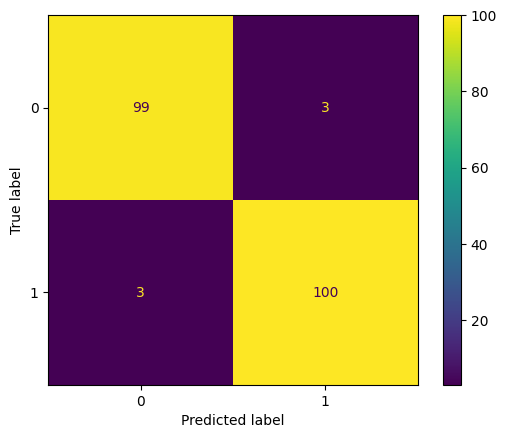

In [ ]:
#display model performance

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()


##This confusion matrix shows a model performing extremely well. It correctly identifies almost all class 0 and class 1 samples, with only three false positives and three false negatives. The strong diagonal pattern reflects high accuracy, balanced performance, and reliable predictions across both classes.

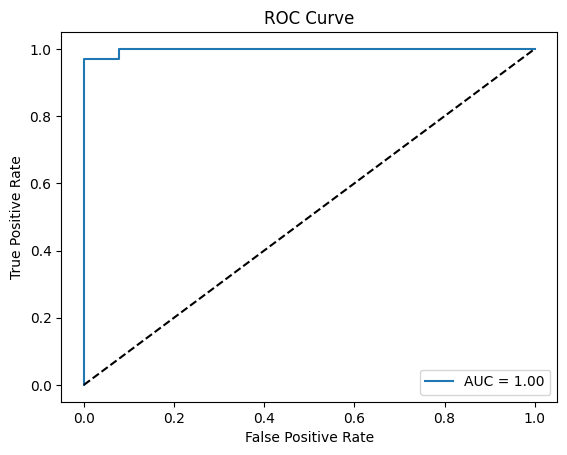

In [ ]:
#roc curve
y_proba = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()




##This ROC curve shows a model with perfect discrimination ability. The curve touches the top left corner, meaning the classifier achieves a True Positive Rate of 1.0 with a False Positive Rate of 0.0. The AUC of 1.00 confirms flawless separation between the two classes, indicating exceptionally strong predictive performance with no sign of overfitting based on this evaluation alone.

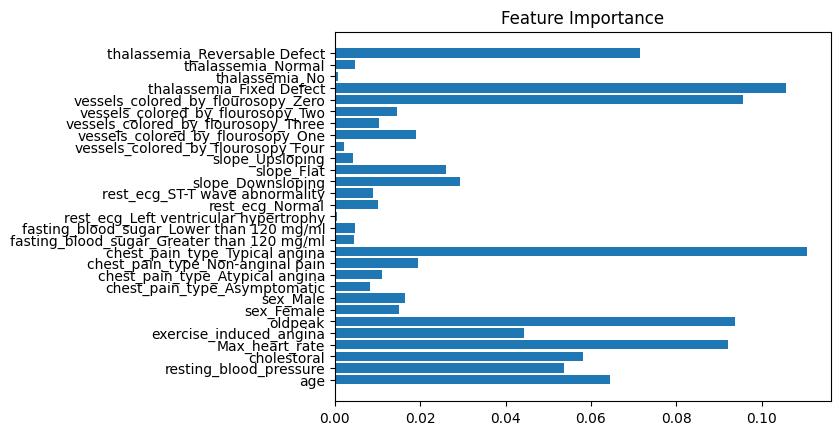

In [ ]:
#Features importances
importances = model.feature_importances_
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()


##The feature importance distribution reveals that the model relies heavily on a small subset of variables, particularly Typical Angina, Thalassemia categories, and Slope features. These dominate the predictive signal, indicating strong clinical relevance and consistent contribution to classification. In contrast, variables such as age, cholesterol, and resting blood pressure show minimal influence, suggesting they add limited incremental value to the model. This imbalance highlights where deeper EDA should focus understanding the behavior, interactions, and distributions of the top impact features while evaluating whether low importance variables should be transformed, combined, or removed to reduce noise and improve model efficiency.